In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import math
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.utils as vutils
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

import random
from datasets import load_dataset

from sklearn.decomposition import PCA

# Air Quality Analysis and LSTM Forecasting

## Task 1

c:\NTHU\深度學習\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\NTHU\深度學習\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38917 (\N{CJK UNIFIED IDEOGRAPH-9805}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


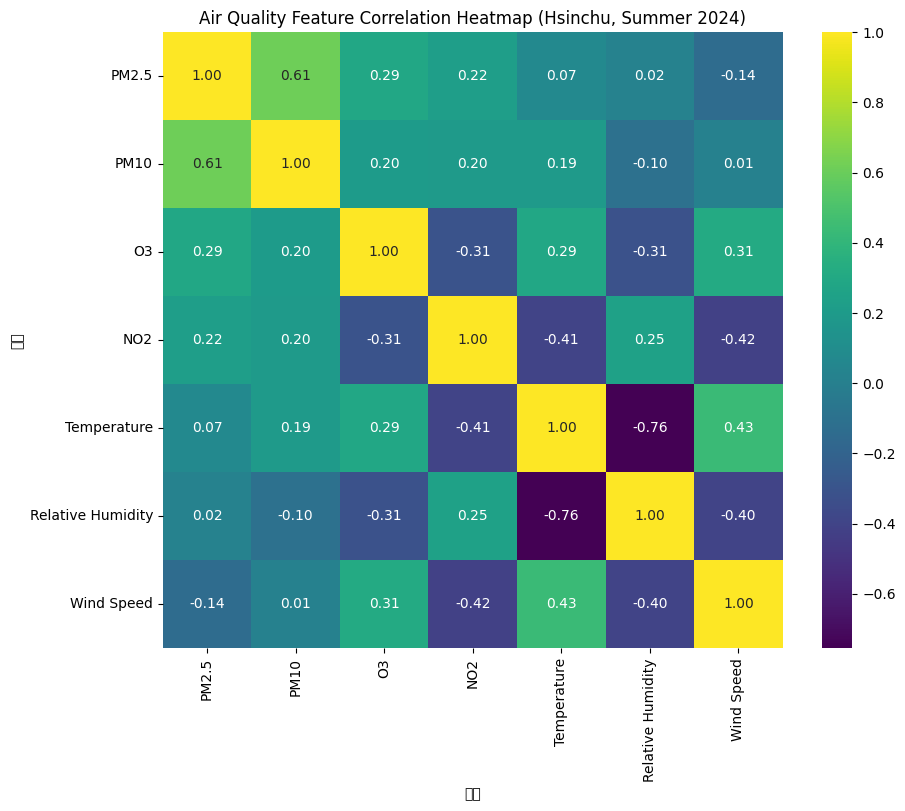

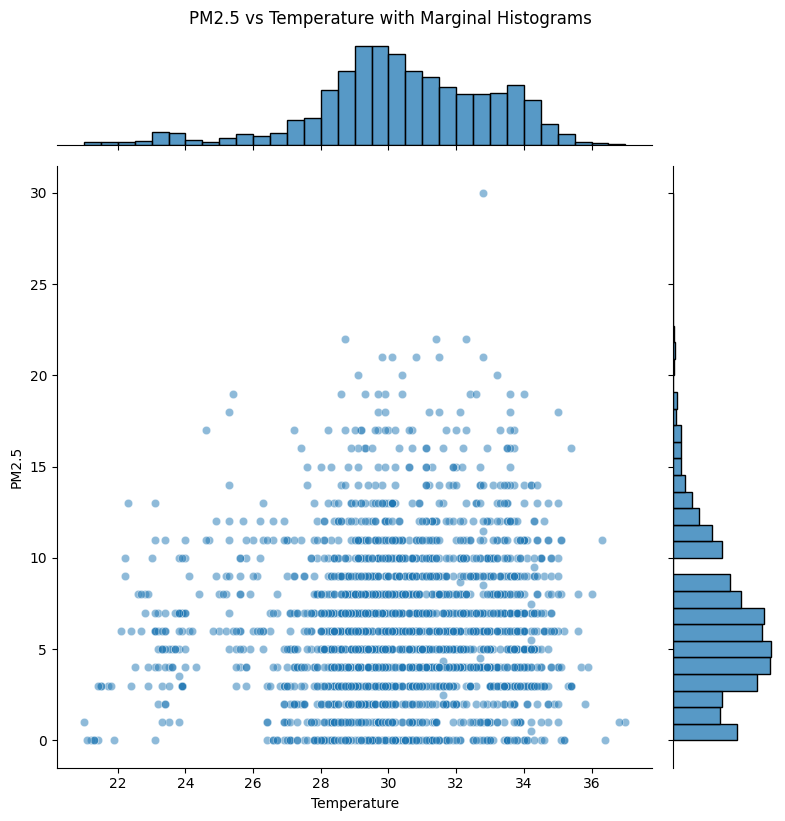

In [2]:
# 1. 讀取檔案
df = pd.read_csv('新竹_2024.csv')

# 2. 資料前處理 (Data Preprocessing)

# 定義 00~23 的小時欄位名稱
hour_columns = [f"{i:02d}" for i in range(24)]

# 轉換格式: 只 melt 我們確定是小時的那些欄位
df_melted = df.melt(id_vars=['測站', '日期', '測項'], value_vars=hour_columns, var_name='Hour', value_name='Value')

# 處理時間: 將 '日期' 和 'Hour' 合併成 datetime 格式
# 注意: 原始日期格式為 YYYY/MM/DD，我們先統一轉成 datetime object
df_melted['Date'] = pd.to_datetime(df_melted['日期']).dt.date
df_melted['Timestamp'] = pd.to_datetime(df_melted['Date'].astype(str) + ' ' + df_melted['Hour'] + ':00:00')

# 轉成數值: 將 'Value' 轉為數字，無法轉的變 NaN (例如 'NR')
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

# 重塑資料 (Pivot): 讓每個測項變成一個欄位
df_pivot = df_melted.pivot(index='Timestamp', columns='測項', values='Value')

# 3. 篩選資料 (Filtering)
# 選取 2024 年夏季 (6月-8月)
df_summer = df_pivot.loc['2024-06-01':'2024-08-31'].copy()

# 選取需要的特徵並重新命名
target_features = {
    'PM2.5': 'PM2.5',
    'PM10': 'PM10',
    'O3': 'O3',
    'NO2': 'NO2',
    'AMB_TEMP': 'Temperature',
    'RH': 'Relative Humidity',
    'WIND_SPEED': 'Wind Speed'
}
df_cleaned = df_summer[list(target_features.keys())].rename(columns=target_features)

# 4. Missing Value Imputation
# 使用線性插值填補缺失值
df_cleaned = df_cleaned.interpolate(method='linear', limit_direction='both')

# 5. Visualization

# (1) Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df_cleaned.corr()
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Air Quality Feature Correlation Heatmap (Hsinchu, Summer 2024)')
plt.show()

# (2) Scatter Plot with Marginal Histograms
# 繪製 PM2.5 vs Temperature
g = sns.jointplot(data=df_cleaned, x='Temperature', y='PM2.5', kind='scatter', alpha=0.5, height=8)
g.fig.suptitle('PM2.5 vs Temperature with Marginal Histograms', y=1.02)
plt.show()


## Task 2

正規化後的數據 (前 3 列):
[[0.1        0.17073171 0.24438202 0.16271186 0.4875     0.71428571
  0.25      ]
 [0.03333333 0.14634146 0.20505618 0.23728814 0.475      0.71428571
  0.09375   ]
 [0.1        0.17073171 0.13202247 0.25084746 0.4625     0.73469388
  0.078125  ]]

--- 資料集形狀檢查 ---
總共有幾筆樣本 (Samples): 2137
X (題目) 形狀: (2137, 48, 7) -> (筆數, 48小時, 7特徵)
y (答案) 形狀: (2137, 24) -> (筆數, 24小時)


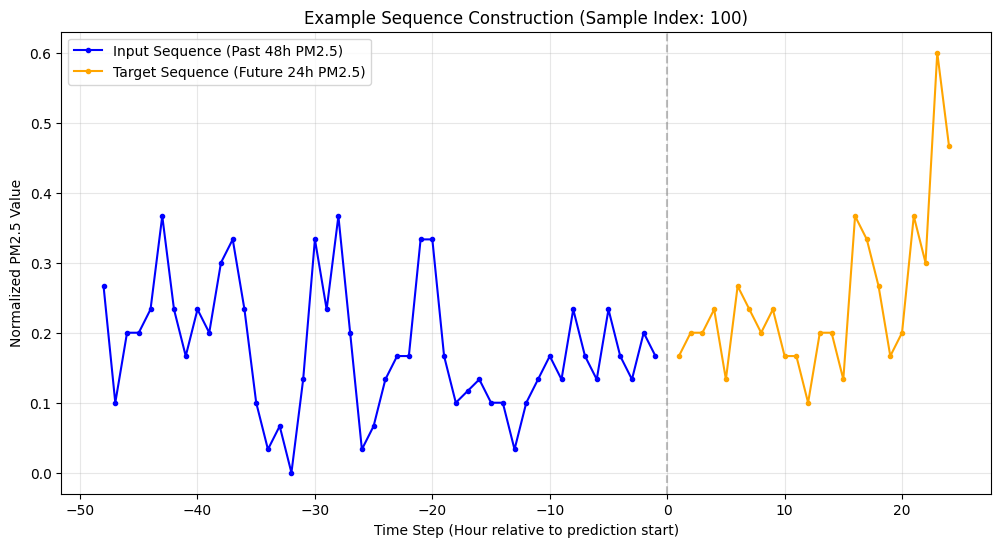

In [3]:
# ==========================================
# 步驟 1: 數據正規化 (Normalization)
# ==========================================

scaler = MinMaxScaler()
# df_cleaned 是 Task 1 留下來的乾淨資料
# fit_transform 會先計算最大最小值，然後把資料轉成 0~1
data_scaled = scaler.fit_transform(df_cleaned)

print("正規化後的數據 (前 3 列):")
print(data_scaled[:3])

# ==========================================
# 步驟 2: 滑動視窗 (Sliding Window) 製作序列
# ==========================================
# 說明: 這就像是在錄影帶上移動一個視窗。
# 每移動一小時，我們就抓取一段「過去48小時」當題目，和「未來24小時」當答案。

def create_sequences(data, input_len=48, output_len=24):
    # data: 已經正規化過的所有資料
    # input_len: 輸入長度 (48小時)
    # output_len: 輸出長度 (24小時)
    
    X = [] # 用來存題目
    y = [] # 用來存答案
    
    # 找出 PM2.5 在第幾個欄位 (因為答案只要預測 PM2.5)
    # 我們在 Task 1 設定 target_features 時，PM2.5 是第一個 (key 0)
    # 為了保險，我們印出來確認一下
    # df_cleaned.columns 的順序就是 data_scaled 的欄位順序
    pm25_index = df_cleaned.columns.get_loc('PM2.5')
    
    total_len = len(data)
    
    # 開始滑動視窗
    # 迴圈範圍：從 0 開始，直到剩下的資料不夠湊成一組 (input + output) 為止
    for i in range(total_len - input_len - output_len + 1):
        # 題目: 從 i 開始，抓 input_len (48) 小時，抓取所有特徵
        input_seq = data[i : i + input_len]
        
        # 答案: 接在題目後面，抓 output_len (24) 小時
        # 注意: 我們只需要預測 PM2.5，所以只抓 pm25_index 這一欄
        output_seq = data[i + input_len : i + input_len + output_len, pm25_index]
        
        X.append(input_seq)
        y.append(output_seq)
        
    return np.array(X), np.array(y)

# 設定長度參數
INPUT_LEN = 48
OUTPUT_LEN = 24

# 執行函式
X, y = create_sequences(data_scaled, INPUT_LEN, OUTPUT_LEN)

# ==========================================
# 步驟 3: 顯示形狀與視覺化範例 
# ==========================================

print("\n--- 資料集形狀檢查 ---")
print(f"總共有幾筆樣本 (Samples): {X.shape[0]}")
print(f"X (題目) 形狀: {X.shape} -> (筆數, 48小時, 7特徵)")
print(f"y (答案) 形狀: {y.shape} -> (筆數, 24小時)")

# 畫出一個範例來檢查
# 我們隨便選第 100 筆資料
sample_idx = 100

plt.figure(figsize=(12, 6))

# 畫出「過去 48 小時」的 PM2.5 (題目)
# X[sample_idx, :, 0] 意思是：第100筆, 所有時間點, 第0個特徵(PM2.5)
# 為了讓圖好看，我們設 X 軸為 -48 到 0
time_x = np.arange(-INPUT_LEN, 0)
plt.plot(time_x, X[sample_idx, :, 0], label='Input Sequence (Past 48h PM2.5)', marker='.', color='blue')

# 畫出「未來 24 小時」的 PM2.5 (真實答案)
# y[sample_idx] 就是那 24 個 PM2.5 數值
time_y = np.arange(1, OUTPUT_LEN + 1)
plt.plot(time_y, y[sample_idx], label='Target Sequence (Future 24h PM2.5)', marker='.', color='orange')

plt.title(f'Example Sequence Construction (Sample Index: {sample_idx})')
plt.xlabel('Time Step (Hour relative to prediction start)')
plt.ylabel('Normalized PM2.5 Value')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5) # 畫一條虛線分隔過去和未來
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 提醒: 
# 我們現在手上有 X 和 y 變數，接下來 Task 3 會把它們拆成 
# 訓練集 (Training)、驗證集 (Validation)、測試集 (Test)。

## Task 3

Using device: cpu
Train size: 1495
Val size:   320
Test size:  322

Starting Training (Epochs: 20, LR: 0.00005)...
Epoch [1/20] | Train Loss: 0.03736 | Val Loss: 0.05792
Epoch [2/20] | Train Loss: 0.02322 | Val Loss: 0.03743
Epoch [3/20] | Train Loss: 0.01589 | Val Loss: 0.02721
Epoch [4/20] | Train Loss: 0.01394 | Val Loss: 0.02527
Epoch [5/20] | Train Loss: 0.01351 | Val Loss: 0.02448
Epoch [6/20] | Train Loss: 0.01319 | Val Loss: 0.02397
Epoch [7/20] | Train Loss: 0.01291 | Val Loss: 0.02248
Epoch [8/20] | Train Loss: 0.01268 | Val Loss: 0.02236
Epoch [9/20] | Train Loss: 0.01245 | Val Loss: 0.02123
Epoch [10/20] | Train Loss: 0.01229 | Val Loss: 0.02101
Epoch [11/20] | Train Loss: 0.01213 | Val Loss: 0.01987
Epoch [12/20] | Train Loss: 0.01204 | Val Loss: 0.01968
Epoch [13/20] | Train Loss: 0.01196 | Val Loss: 0.01973
Epoch [14/20] | Train Loss: 0.01191 | Val Loss: 0.01893
Epoch [15/20] | Train Loss: 0.01186 | Val Loss: 0.01893
Epoch [16/20] | Train Loss: 0.01184 | Val Loss: 0.0192

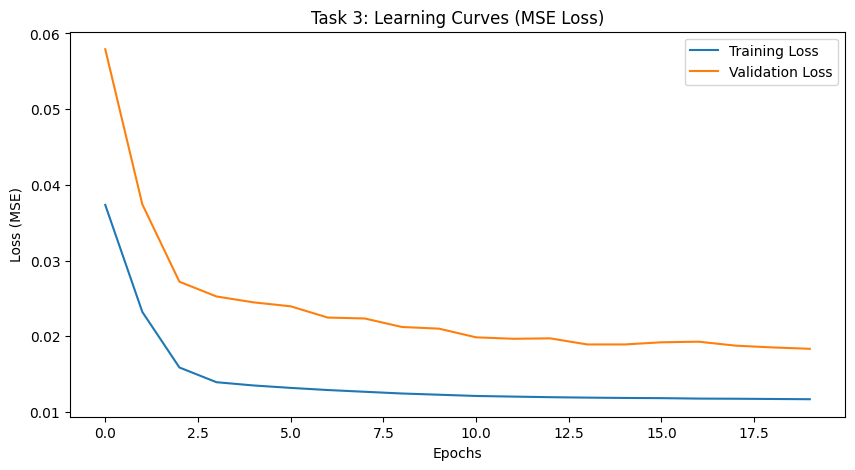


--- Quantitative Metrics (Test Set) ---
MAE  (Mean Absolute Error):       3.6046
RMSE (Root Mean Squared Error):   4.5971
MAPE (Mean Abs. Percentage Err.): 29306005.5160%


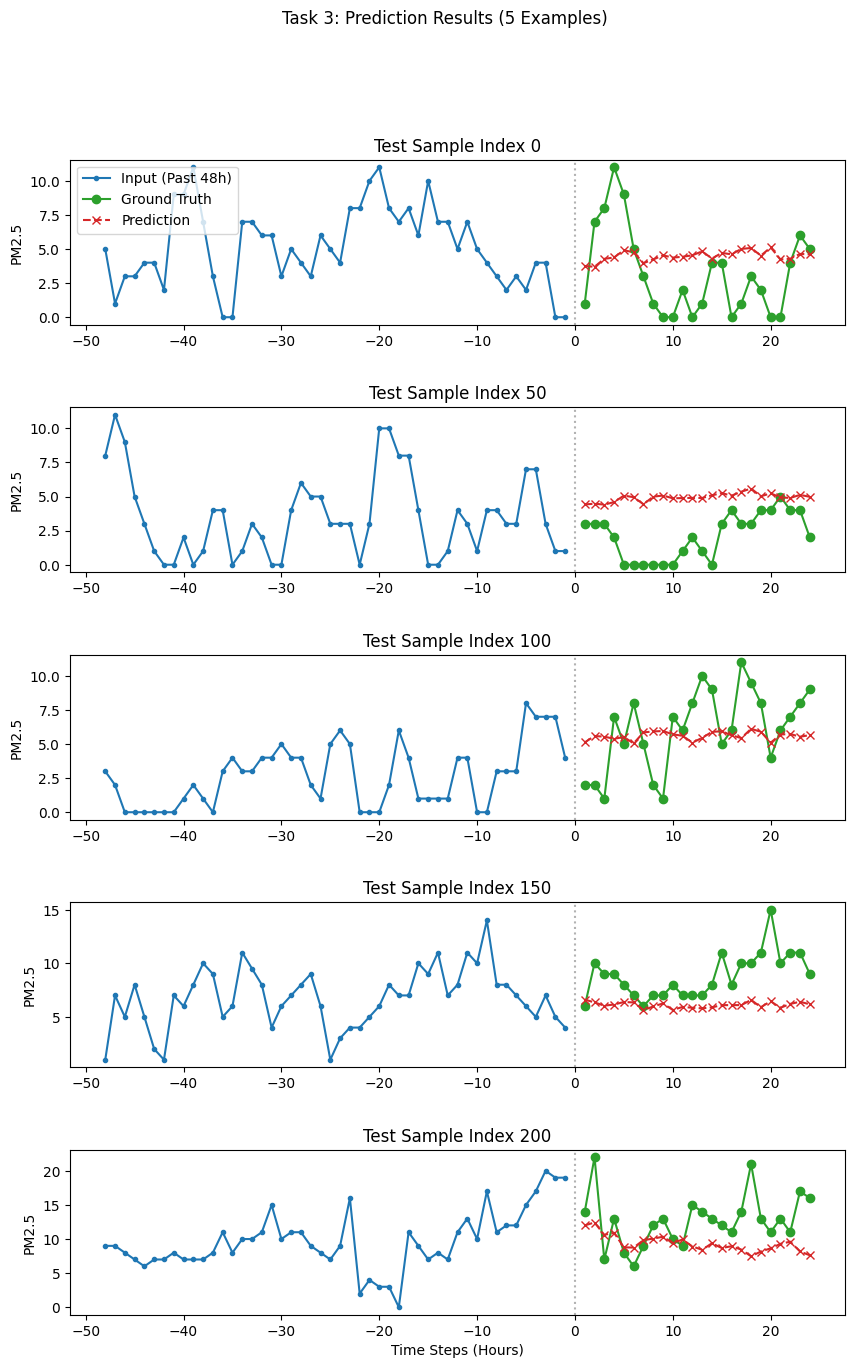


--- 程式碼執行結束 ---


In [4]:
device = torch.device("cpu")
print(f"Using device: {device}")

# ==========================================
# 1. 資料集分割 (Train/Val/Test Split)
# ==========================================
# 假設 X, y 已經在記憶體中
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)
test_size = total_samples - train_size - val_size

# 轉成 PyTorch Tensor
X_tensor = torch.FloatTensor(X).to(device)
y_tensor = torch.FloatTensor(y).to(device)

# 切割 (Chronological split)
X_train, y_train = X_tensor[:train_size], y_tensor[:train_size]
X_val, y_val = X_tensor[train_size:train_size+val_size], y_tensor[train_size:train_size+val_size]
X_test, y_test = X_tensor[train_size+val_size:], y_tensor[train_size+val_size:]

print(f"Train size: {len(X_train)}")
print(f"Val size:   {len(X_val)}")
print(f"Test size:  {len(X_test)}")

# ==========================================
# 2. 手刻 LSTM 模型 (Manual LSTM Implementation)
# ==========================================
class ManualLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ManualLSTM, self).__init__()
        self.hidden_size = hidden_size
        
        # 權重定義: 4個 Gates (i, f, g, o)
        self.W_x = nn.Linear(input_size, hidden_size * 4) 
        self.W_h = nn.Linear(hidden_size, hidden_size * 4)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        c_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        for t in range(seq_len):
            x_t = x[:, t, :]
            gates = self.W_x(x_t) + self.W_h(h_t)
            i_gate, f_gate, g_gate, o_gate = gates.chunk(4, 1)
            
            i_t = torch.sigmoid(i_gate)
            f_t = torch.sigmoid(f_gate)
            g_t = torch.tanh(g_gate)
            o_t = torch.sigmoid(o_gate)
            
            c_t = f_t * c_t + i_t * g_t
            h_t = o_t * torch.tanh(c_t)
            
        return self.fc(h_t)

# 參數設定
input_dim = 7
output_dim = 24
# *** 修正點 1: 隱藏層維度增加 ***
hidden_dim = 128 

model = ManualLSTM(input_size=input_dim, hidden_size=hidden_dim, output_size=output_dim).to(device)
criterion = nn.MSELoss()
# *** 修正點 2: 學習率降低 ***
optimizer = optim.Adam(model.parameters(), lr=0.00005) 

# 訓練迴圈 (Training Loop)
# *** 修正點 3: 訓練輪數增加 ***
epochs = 20 
batch_size = 32
train_losses = []
val_losses = []

print(f"\nStarting Training (Epochs: {epochs}, LR: 0.00005)...")

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train.size()[0])
    epoch_loss = 0
    
    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[indices], y_train[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss / (X_train.size()[0] / batch_size)
    train_losses.append(avg_train_loss)
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val).item()
        val_losses.append(val_loss)
    
    # *** 修正點 4: 每輪都顯示 Loss ***
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss: {val_loss:.5f}")

# [Task 3 Output 1] Loss 曲線
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Task 3: Learning Curves (MSE Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# ==========================================
# 評估與視覺化 (Evaluation & Visualization)
# ==========================================

# 反正規化 (Inverse Transform) 函式
pm25_min = scaler.min_[0]
pm25_scale = scaler.scale_[0]

def inverse_pm25(scaled_value):
    # MinMaxScaler 反轉公式: X = (X_scaled - min_) / scale_
    return (scaled_value - pm25_min) / pm25_scale

# 執行預測並還原數值
model.eval()
with torch.no_grad():
    test_preds = model(X_test).cpu().numpy()
    y_true = y_test.cpu().numpy()
    X_test_cpu = X_test.cpu().numpy()

preds_real = inverse_pm25(test_preds)
y_true_real = inverse_pm25(y_true)
input_real = inverse_pm25(X_test_cpu[:, :, 0]) 

# 計算指標 (Metrics)
mae = np.mean(np.abs(y_true_real - preds_real))
rmse = np.sqrt(np.mean((y_true_real - preds_real)**2))
mape = np.mean(np.abs((y_true_real - preds_real) / (y_true_real + 1e-6))) * 100

print("\n--- Quantitative Metrics (Test Set) ---")
print(f"MAE  (Mean Absolute Error):       {mae:.4f}")
print(f"RMSE (Root Mean Squared Error):   {rmse:.4f}")
print(f"MAPE (Mean Abs. Percentage Err.): {mape:.4f}%") # 忽略數值爆炸問題

# [Task 3 Output 2] 繪製 5 個預測範例
sample_indices = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(5, 1, figsize=(10, 15))
plt.subplots_adjust(hspace=0.5)

for i, idx in enumerate(sample_indices):
    ax = axes[i]
    
    t_input = np.arange(-48, 0)
    t_output = np.arange(1, 25)
    
    ax.plot(t_input, input_real[idx], label='Input (Past 48h)', color='#1f77b4', marker='.')
    ax.plot(t_output, y_true_real[idx], label='Ground Truth', color='#2ca02c', marker='o')
    ax.plot(t_output, preds_real[idx], label='Prediction', color='#d62728', linestyle='--', marker='x')
    
    ax.set_title(f'Test Sample Index {idx}')
    ax.set_ylabel('PM2.5')
    ax.axvline(0, color='gray', linestyle=':', alpha=0.6)
    
    if i == 0:
        ax.legend(loc='upper left')

plt.xlabel('Time Steps (Hours)')
plt.suptitle('Task 3: Prediction Results (5 Examples)')
plt.show()

print("\n--- 程式碼執行結束 ---")

# Lego Minifigure Generation

## Task 1

Using device: cpu
Loading dataset from Hugging Face...
Total images found: 12966
Train size: 9076
Val size:   2593
Test size:  1297

Visualizing a grid of sampled Minifigure images...


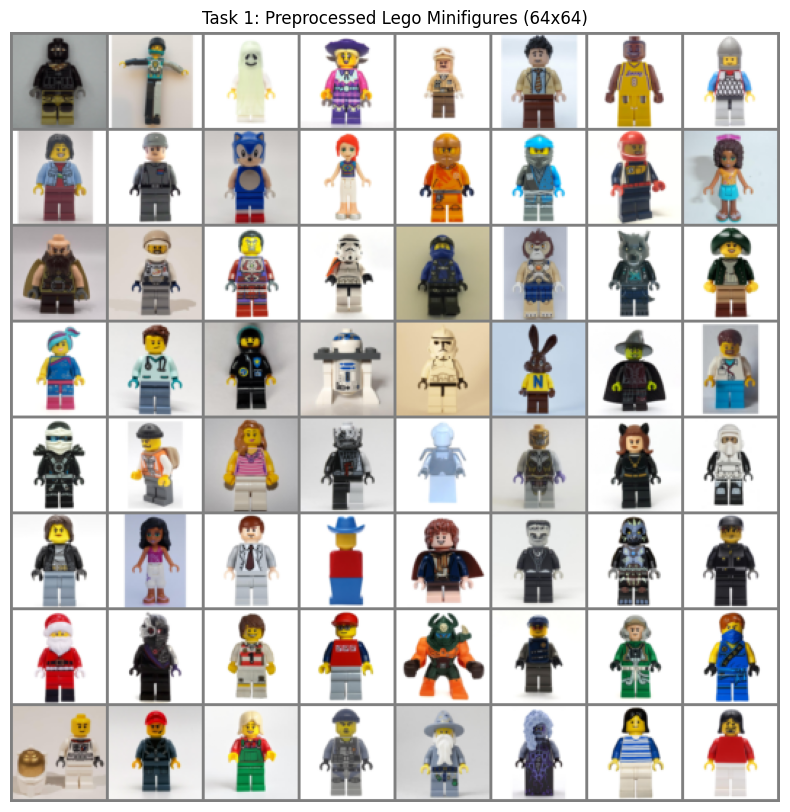

In [4]:
# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# 檢查裝置 (VAE 建議使用 GPU，若您想強制用 CPU 可自行修改)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. 載入資料集 (Load Dataset)
# ==========================================
print("Loading dataset from Hugging Face...")
# 根據作業要求載入指定資料集
dataset = load_dataset("Armaggheddon/lego_minifigure_captions", split="train")

print(f"Total images found: {len(dataset)}")

# ==========================================
# 2. 預處理與正規化 (Preprocessing)
# ==========================================
# 作業要求: Resize to 64x64, Normalize
image_size = 64
batch_size = 64

# 定義轉換 (Transforms)
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)), # 調整大小
    transforms.ToTensor(),                       # 轉為 Tensor (0~1)
    # 正規化: 這裡使用常見的 (0.5, 0.5, 0.5) 讓數值分佈在 -1 ~ 1 之間
    # 這對於 Tanh 激活函數的最後一層輸出很有幫助，或者也可以維持 0~1
    # 這裡我們先正規化到 [-1, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

# 自定義 PyTorch Dataset Wrapper 以便套用 transform
class LegoDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        item = self.hf_dataset[idx]
        image = item['image'] # HuggingFace dataset 的圖片欄位通常叫 'image'
        
        # 確保圖片是 RGB
        if image.mode != 'RGB':
            image = image.convert('RGB')
            
        if self.transform:
            image = self.transform(image)
            
        return image

# 建立 Dataset 物件
full_dataset = LegoDataset(dataset, transform=transform)

# ==========================================
# 3. 資料分割 (Train/Val/Test Split)
# ==========================================
# 常見比例: 80% Train, 10% Val, 10% Test
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")
print(f"Test size:  {len(test_dataset)}")

# 建立 DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==========================================
# 4. 視覺化檢查 (Visualization)
# ==========================================
# 輔助函式: 反正規化並顯示圖片
def imshow(img, title="Sample Images"):
    # img is in [-1, 1] range (because of Normalize)
    # unnormalize to [0, 1]
    img = img / 2 + 0.5 
    npimg = img.numpy()
    plt.figure(figsize=(10, 10))
    # transpose: (C, H, W) -> (H, W, C)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

# 取得一個 batch 的圖片
dataiter = iter(train_loader)
images = next(dataiter)

# 製作網格圖 (Make Grid)
print("\nVisualizing a grid of sampled Minifigure images...")
grid_img = torchvision.utils.make_grid(images[:64], nrow=8) # 顯示前 64 張
imshow(grid_img, title="Task 1: Preprocessed Lego Minifigures (64x64)")

## Task 2

Start Training VAE (Latent Dim=128)...
Epoch [5/30] | Loss: 771.3151 (Recon: 701.17, KL: 70.15) | Val Loss: 688.6055
Epoch [10/30] | Loss: 529.3087 (Recon: 454.55, KL: 74.76) | Val Loss: 511.3332
Epoch [15/30] | Loss: 454.4295 (Recon: 374.91, KL: 79.52) | Val Loss: 440.8554
Epoch [20/30] | Loss: 417.3587 (Recon: 336.17, KL: 81.19) | Val Loss: 424.2146
Epoch [25/30] | Loss: 394.0237 (Recon: 311.47, KL: 82.56) | Val Loss: 403.9130
Epoch [30/30] | Loss: 373.4539 (Recon: 289.71, KL: 83.75) | Val Loss: 393.3979


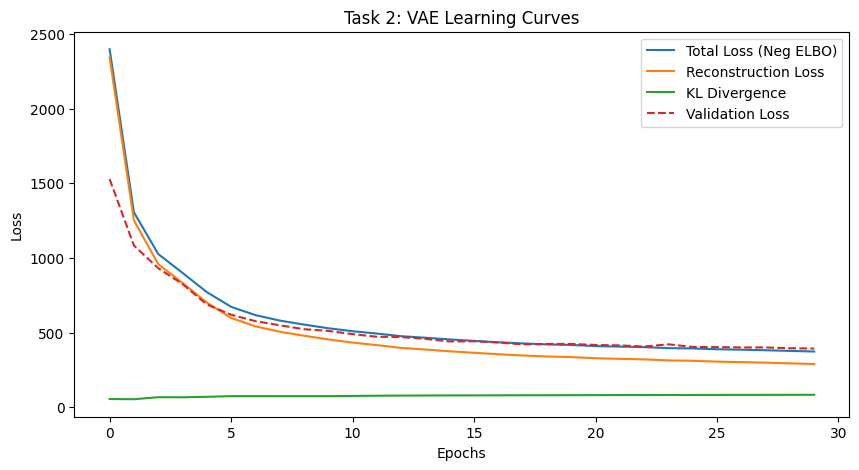

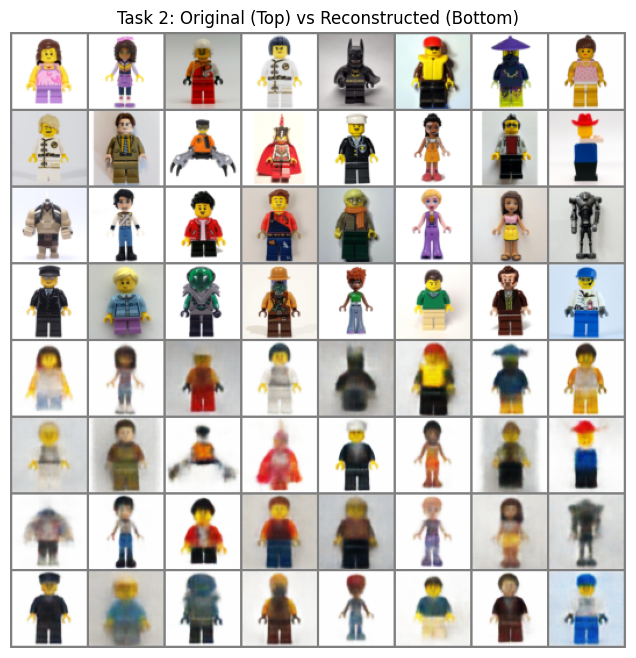

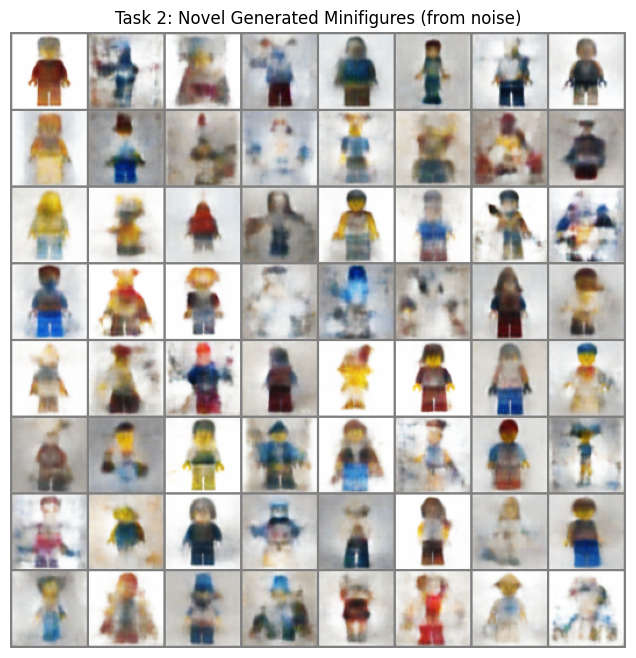

Task 2 Completed.


In [ ]:
# ==========================================
# 1. 定義 VAE 模型 (Convolutional VAE)
# ==========================================
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # --- Encoder (卷積層) ---
        # Input: (3, 64, 64)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # -> (32, 32, 32)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # -> (64, 16, 16)
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # -> (128, 8, 8)
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # -> (256, 4, 4)
            nn.ReLU(),
        )
        
        # Flatten size: 256 * 4 * 4 = 4096
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)
        
        # --- Decoder (反卷積層) ---
        self.decoder_input = nn.Linear(latent_dim, 256 * 4 * 4)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # -> (128, 8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> (64, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # -> (32, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # -> (3, 64, 64)
            nn.Tanh() # 輸出範圍 [-1, 1]，配合 Task 1 的 Normalize((0.5), (0.5))
        )

    def reparameterize(self, mu, logvar):
        """
        Reparameterization Trick: z = mu + sigma * epsilon
        """
        if self.training:
            std = torch.exp(0.5 * logvar) # logvar -> std
            eps = torch.randn_like(std)   # 從標準常態分佈採樣 epsilon
            return mu + eps * std
        else:
            return mu

    def forward(self, x):
        # 1. Encode
        h = self.encoder(x)
        h = h.view(h.size(0), -1) # Flatten
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        # 2. Reparameterize
        z = self.reparameterize(mu, logvar)
        
        # 3. Decode
        h_dec = self.decoder_input(z)
        h_dec = h_dec.view(h_dec.size(0), 256, 4, 4) # Unflatten
        reconstruction = self.decoder(h_dec)
        
        return reconstruction, mu, logvar

# ==========================================
# 2. 定義 Loss Function (ELBO)
# ==========================================
def loss_function(recon_x, x, mu, logvar, beta=1.0):
    # 1. Reconstruction Loss (MSE)
    # 因為我們用 Tanh 輸出 [-1, 1]，MSE 是合適的選擇
    # reduction='sum' 表示將一個 batch 的所有誤差加總
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # 2. KL Divergence
    # 公式: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # ELBO Loss = Recon + beta * KL
    return recon_loss + beta * kld_loss, recon_loss, kld_loss

# ==========================================
# 3. 訓練迴圈 (Training Loop)
# ==========================================
latent_dim = 128
model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 30 # 可以根據時間調整，通常 20-50 輪效果不錯
train_losses = []
val_losses = []
kl_losses = []
recon_losses = []

print(f"Start Training VAE (Latent Dim={latent_dim})...")

for epoch in range(epochs):
    model.train()
    train_loss = 0
    total_recon = 0
    total_kl = 0
    
    for batch_idx, data in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        
        # 計算 Loss (beta=1 for base model)
        loss, recon, kld = loss_function(recon_batch, data, mu, logvar, beta=1.0)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        total_recon += recon.item()
        total_kl += kld.item()
        
    # 計算平均 Loss
    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon = total_recon / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)
    
    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            recon, mu, logvar = model(data)
            loss, _, _ = loss_function(recon, data, mu, logvar)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    
    print(f'Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} (Recon: {avg_recon:.2f}, KL: {avg_kl:.2f}) | Val Loss: {avg_val_loss:.4f}')

# ==========================================
# 4. 結果報告與視覺化 (Visualization)
# ==========================================
# [Requirement 1] Learning Curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Total Loss (Neg ELBO)')
plt.plot(recon_losses, label='Reconstruction Loss')
plt.plot(kl_losses, label='KL Divergence')
plt.plot(val_losses, label='Validation Loss', linestyle='--')
plt.title('Task 2: VAE Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Helper function for visualization
def show_image_grid(img_tensor, title):
    img_tensor = img_tensor.cpu()
    # Unnormalize: [-1, 1] -> [0, 1]
    img_tensor = img_tensor / 2 + 0.5
    npimg = img_tensor.numpy()
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

# [Requirement 2] Original vs Reconstructed
model.eval()
with torch.no_grad():
    # 拿一組測試資料
    test_batch = next(iter(test_loader)).to(device)
    recon_batch, _, _ = model(test_batch)
    
    # 取前 32 張來比較
    n_show = 32
    compare_img = torch.cat([test_batch[:n_show], recon_batch[:n_show]])
    grid_compare = torchvision.utils.make_grid(compare_img, nrow=8)
    
    show_image_grid(grid_compare, "Task 2: Original (Top) vs Reconstructed (Bottom)")

# [Requirement 3] Novel Generation (Sampling from z ~ N(0, I))
model.eval()
with torch.no_grad():
    # 生成 64 張新圖片
    z = torch.randn(64, latent_dim).to(device) # z ~ N(0, I)
    
    # 通過 Decoder
    # 注意: 模型中的 decoder 包含 decoder_input 和 conv layers
    h_dec = model.decoder_input(z)
    h_dec = h_dec.view(h_dec.size(0), 256, 4, 4)
    generated_imgs = model.decoder(h_dec)
    
    grid_gen = torchvision.utils.make_grid(generated_imgs, nrow=8)
    show_image_grid(grid_gen, "Task 2: Novel Generated Minifigures (from noise)")

print("Task 2 Completed.")

## Task 3

Total latent vectors extracted: (1297, 128)


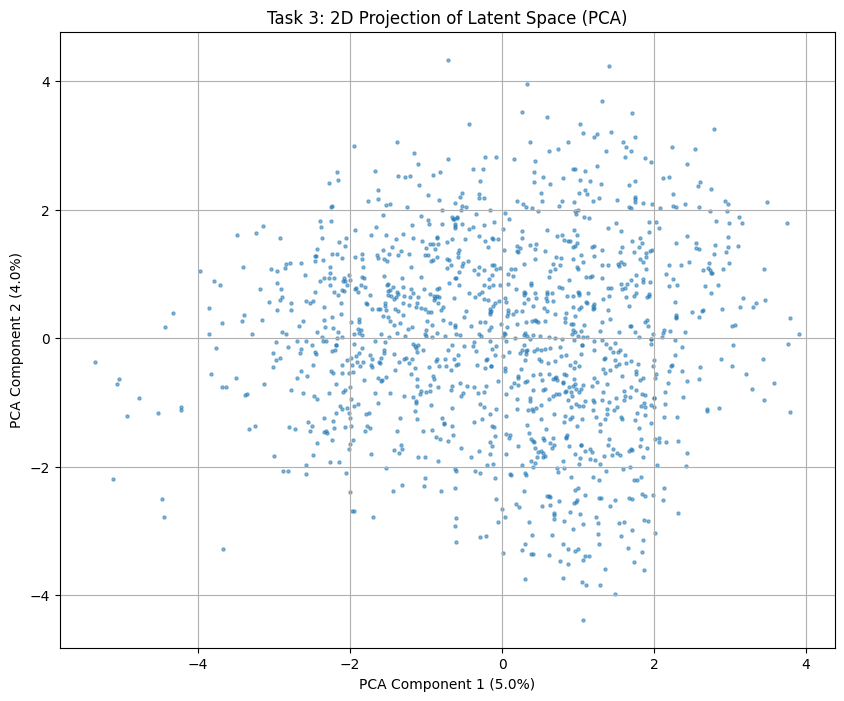

In [14]:

# 假設 model 和 test_loader 已經存在於記憶體中
model.eval()

# 1. 提取潛在向量 (Latent Vectors)
latent_vectors = []
for data in test_loader:
    data = data.to(device)
    with torch.no_grad():
        # 只取 mu (平均值) 作為潛在向量 z 的代表
        h = model.encoder(data)
        h = h.view(h.size(0), -1)
        mu = model.fc_mu(h)
        latent_vectors.append(mu.cpu().numpy())

Z = np.concatenate(latent_vectors, axis=0)
print(f"Total latent vectors extracted: {Z.shape}")

# 2. PCA 降維至 2D
pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

# 3. 視覺化潛在空間
plt.figure(figsize=(10, 8))
# 我們可以將 PM2.5 的概念應用到這裡: 依照潛在向量的 L2 範數來給點上色 (輔助分析)
# 這裡簡單繪製，顏色統一
plt.scatter(Z_2d[:, 0], Z_2d[:, 1], alpha=0.5, s=5)
plt.title('Task 3: 2D Projection of Latent Space (PCA)')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True)
plt.show()

Total raw data vectors extracted: (1297, 12288)
Dimension of each image vector: 12288


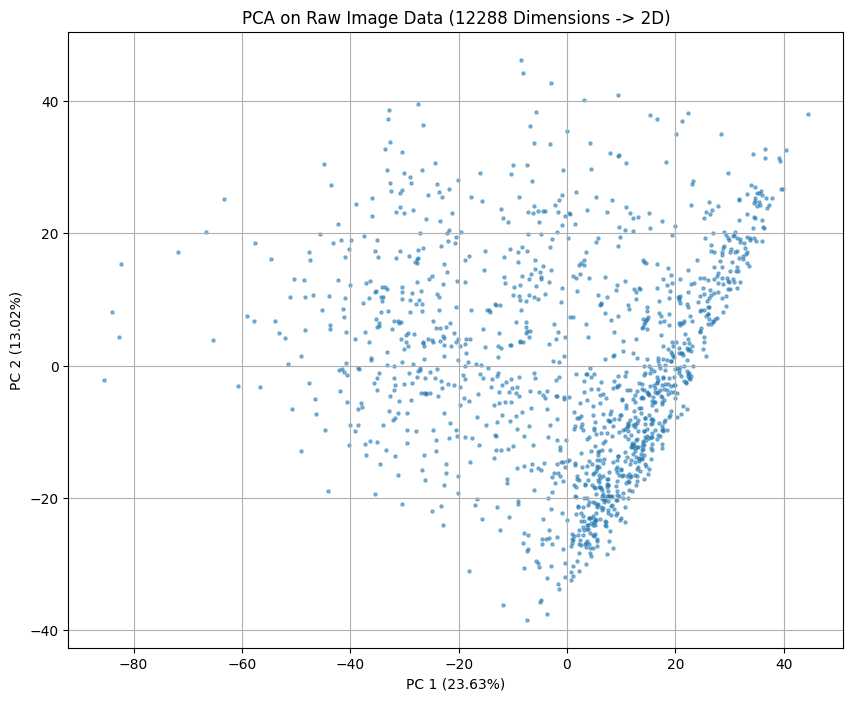

Total variance explained by the first two components: 36.65%


In [15]:
# 警告: 請確保您已執行 Part II 的 Task 1 (資料準備)，
# 且 train_loader, val_loader, test_loader 變數已存在於記憶體中。

# ==========================================
# 執行 PCA on Raw Image Data
# ==========================================

# 1. 提取原始圖片數據並展平 (Flatten Raw Data)
raw_data_vectors = []

# 迭代 test_loader，將所有圖片轉換為 NumPy 陣列
for data in test_loader:
    # data: (Batch_size, 3, 64, 64)
    # 展平: (Batch_size, 3 * 64 * 64 = 12288)
    flattened_batch = data.view(data.size(0), -1)
    raw_data_vectors.append(flattened_batch.cpu().numpy())

X_raw = np.concatenate(raw_data_vectors, axis=0)
print(f"Total raw data vectors extracted: {X_raw.shape}")
print(f"Dimension of each image vector: {X_raw.shape[1]}") 

# 2. PCA 降維至 2D
pca_raw = PCA(n_components=2)
X_2d = pca_raw.fit_transform(X_raw)

# 3. 視覺化原始數據的 PCA 空間
plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=5)
plt.title('PCA on Raw Image Data (12288 Dimensions -> 2D)')
plt.xlabel(f'PC 1 ({pca_raw.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC 2 ({pca_raw.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.show()

# 4. 報告總解釋方差
total_variance = pca_raw.explained_variance_ratio_.sum()
print(f"Total variance explained by the first two components: {total_variance*100:.2f}%")

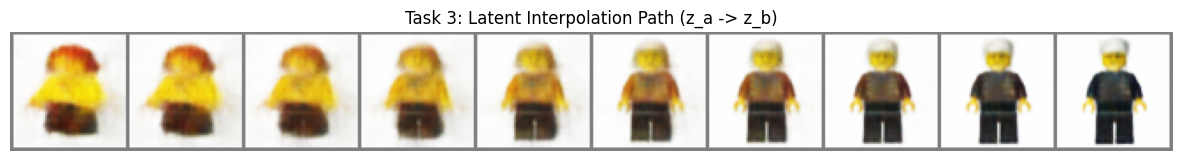

In [18]:
# 1. 選取兩張測試圖片 (Index)
idx_a = 0
idx_b = 50 

test_images = test_loader.dataset.dataset # 取得原始 Dataset 物件 (包含所有圖片)
img_a = test_images[idx_a]
img_b = test_images[idx_b]

# 將圖片轉成 batch 形式並送入模型
imgs_ab = torch.stack([img_a, img_b]).to(device)

# 2. 取得潛在向量 z_a 和 z_b
model.eval()
with torch.no_grad():
    h = model.encoder(imgs_ab)
    h = h.view(h.size(0), -1)
    mu = model.fc_mu(h)
    
    z_a = mu[0]
    z_b = mu[1]

# 3. 生成插值路徑 (z(alpha))
n_steps = 10
interpolated_z = []
for i in range(n_steps):
    alpha = i / (n_steps - 1)
    # 線性插值公式: z(alpha) = (1 - alpha) * z_a + alpha * z_b
    z_alpha = (1 - alpha) * z_a + alpha * z_b
    interpolated_z.append(z_alpha)

interpolated_z = torch.stack(interpolated_z).to(device)

# 4. 解碼並視覺化
with torch.no_grad():
    # 注意：這裡複製 Task 2 的解碼邏輯
    h_dec = model.decoder_input(interpolated_z)
    h_dec = h_dec.view(h_dec.size(0), 256, 4, 4)
    interpolated_imgs = model.decoder(h_dec)

# 將所有圖像組合成網格
grid_interp = vutils.make_grid(interpolated_imgs, nrow=n_steps)

# 輔助函式: 反正規化並顯示圖片
def show_image_grid_simple(img_tensor, title):
    img_tensor = img_tensor.cpu()
    img_tensor = img_tensor / 2 + 0.5
    npimg = img_tensor.numpy()
    plt.figure(figsize=(15, 3))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

show_image_grid_simple(grid_interp, "Task 3: Latent Interpolation Path (z_a -> z_b)")


--- Starting Beta=0.0 Experiment ---
Beta=0.0 | Epoch [1/15] | Loss: 1894.7887
Beta=0.0 | Epoch [2/15] | Loss: 963.3693
Beta=0.0 | Epoch [3/15] | Loss: 785.0097
Beta=0.0 | Epoch [4/15] | Loss: 644.7283
Beta=0.0 | Epoch [5/15] | Loss: 516.3302
Beta=0.0 | Epoch [6/15] | Loss: 460.9776
Beta=0.0 | Epoch [7/15] | Loss: 421.4634
Beta=0.0 | Epoch [8/15] | Loss: 386.6925
Beta=0.0 | Epoch [9/15] | Loss: 356.7184
Beta=0.0 | Epoch [10/15] | Loss: 335.8035
Beta=0.0 | Epoch [11/15] | Loss: 319.5217
Beta=0.0 | Epoch [12/15] | Loss: 304.3864
Beta=0.0 | Epoch [13/15] | Loss: 291.6449
Beta=0.0 | Epoch [14/15] | Loss: 281.3169
Beta=0.0 | Epoch [15/15] | Loss: 270.8966

--- Starting Beta=100.0 Experiment ---
Beta=100.0 | Epoch [1/15] | Loss: 2836.1869
Beta=100.0 | Epoch [2/15] | Loss: 1792.0366
Beta=100.0 | Epoch [3/15] | Loss: 1711.6210
Beta=100.0 | Epoch [4/15] | Loss: 1695.9352
Beta=100.0 | Epoch [5/15] | Loss: 1675.8854
Beta=100.0 | Epoch [6/15] | Loss: 1663.3656
Beta=100.0 | Epoch [7/15] | Loss: 16

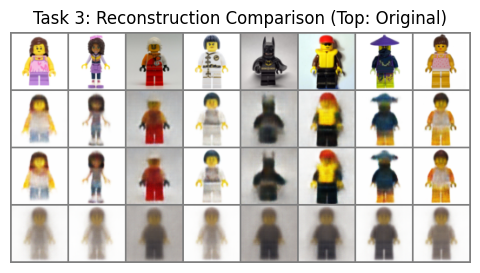

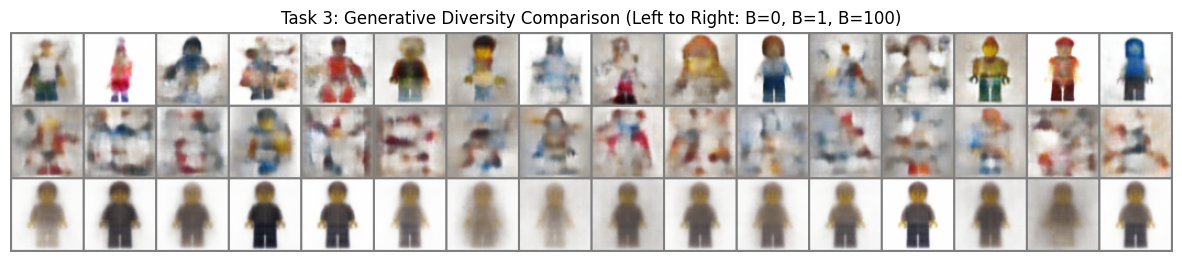

In [20]:
# 設定實驗參數
BETAS = [0.0, 100.0] 
EPOCHS_BETA = 15 # 為加速實驗，減少輪數

# 儲存結果用的字典
beta_models = {1.0: model} # 放入 Task 2 訓練好的模型
results_summary = {}

# 載入 Task 2 的 VAE class (為了重複使用)
# (假設 VAE class 定義已在記憶體中)

def run_beta_experiment(beta_value, original_model, epochs):
    print(f"\n--- Starting Beta={beta_value} Experiment ---")
    
    # 複製 Task 2 的模型結構 (但權重是新的)
    new_model = VAE(latent_dim=original_model.latent_dim).to(device)
    optimizer = optim.Adam(new_model.parameters(), lr=1e-3)
    
    for epoch in range(epochs):
        new_model.train()
        train_loss = 0
        
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            
            recon_batch, mu, logvar = new_model(data)
            
            # 使用新的 Beta 值計算 Loss
            loss, recon, kld = loss_function(recon_batch, data, mu, logvar, beta=beta_value)
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader.dataset)
        print(f'Beta={beta_value} | Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f}')
             
    return new_model

# 執行 Beta 實驗
for beta in BETAS:
    if beta not in beta_models:
        # 傳入 Task 2 模型作為結構參考
        beta_models[beta] = run_beta_experiment(beta, model, EPOCHS_BETA)

# --- 比較與視覺化 ---

# 輔助函式: 生成圖像並組裝比較
def generate_and_compare(models_dict):
    all_originals = []
    all_recons = []
    all_gens = []
    
    # 從測試集取一組圖片進行重建
    test_batch = next(iter(test_loader)).to(device)
    
    # 固定一個潛在向量 Z 用於生成比較
    fixed_z = torch.randn(16, model.latent_dim).to(device)

    for beta, m in models_dict.items():
        m.eval()
        with torch.no_grad():
            # 1. 重建圖像
            recon, _, _ = m(test_batch[:8])
            all_recons.append(recon)
            
            # 2. 生成圖像
            h_dec = m.decoder_input(fixed_z)
            h_dec = h_dec.view(h_dec.size(0), 256, 4, 4)
            generated_imgs = m.decoder(h_dec)
            all_gens.append(generated_imgs)
            
            if beta == 1.0:
                 all_originals.append(test_batch[:8])

    # 組合重建比較圖
    # (Originals, Beta=0 Recon, Beta=1 Recon, Beta=100 Recon)
    recon_comparison = torch.cat(all_originals + all_recons, dim=0)
    grid_recon = vutils.make_grid(recon_comparison, nrow=8)
    
    # 組合生成比較圖
    # (Beta=0 Gen, Beta=1 Gen, Beta=100 Gen)
    gen_comparison = torch.cat(all_gens, dim=0)
    grid_gen = vutils.make_grid(gen_comparison, nrow=16)

    show_image_grid_simple(grid_recon, "Task 3: Reconstruction Comparison (Top: Original)")
    show_image_grid_simple(grid_gen, "Task 3: Generative Diversity Comparison (Left to Right: B=0, B=1, B=100)")
    
    return beta_models

# 執行比較
final_beta_models = generate_and_compare(beta_models)